[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/langchain-ai/langchain-academy/blob/main/module-4/map-reduce.ipynb) [![Open in LangChain Academy](https://cdn.prod.website-files.com/65b8cd72835ceeacd4449a53/66e9eba12c7b7688aa3dbb5e_LCA-badge-green.svg)](https://academy.langchain.com/courses/take/intro-to-langgraph/lessons/58239947-lesson-3-map-reduce)

# Map-Reduce（映射-归约）

## 回顾（Review）

我们正在逐步构建一个多智能体（multi-agent）研究助理，它会把本课程中的各个模块串联起来。

为构建这个多智能体助理，我们已经介绍了一些 LangGraph 的“可控性”主题。

上一节我们学习了并行化（parallelization）和子图（sub-graphs）。

## 目标（Goals）

本节我们将学习 [Map-Reduce](https://langchain-ai.github.io/langgraph/how-tos/map-reduce/) 模式。

In [ ]:
%%capture --no-stderr
%pip install -U langchain_openai langgraph

In [ ]:
import os, getpass

def _set_env(var: str):
    if not os.environ.get(var):
        os.environ[var] = getpass.getpass(f"{var}: ")

_set_env("OPENAI_API_KEY")

我们将使用 [LangSmith](https://docs.smith.langchain.com/) 进行[链路追踪（tracing）](https://docs.smith.langchain.com/concepts/tracing)。这可以帮助初学者观察每一步调用与中间结果，便于调试与理解。

In [ ]:
_set_env("LANGSMITH_API_KEY")
os.environ["LANGSMITH_TRACING"] = "true"
os.environ["LANGSMITH_PROJECT"] = "langchain-academy"

## 问题（Problem）

Map-Reduce 是一种高效的任务拆解与并行处理模式，通常分为两个阶段：

1) `Map`（映射）：把一个大任务拆分为多个可并行处理的小任务。

2) `Reduce`（归约）：汇总所有并行子任务的结果，并得到最终输出。

我们来设计一个简单系统来演示这个思想，做两件事：

1) `Map`：围绕某个主题生成一组笑话（每个子主题各出一个）。

2) `Reduce`：从生成的笑话中挑选出最好的一条。

我们将使用大语言模型（LLM）来完成“生成候选（Map）”与“选择最佳（Reduce）”。

In [ ]:
from langchain_openai import ChatOpenAI

# 将使用的提示词（Prompts）：
# - 生成与主题相关的 3 个子主题
subjects_prompt = """Generate a list of 3 sub-topics that are all related to this overall topic: {topic}."""
# - 针对某个子主题生成一个笑话
joke_prompt = """Generate a joke about {subject}"""
# - 在一组笑话中选择最佳的一条，并返回其索引（从 0 开始计数）
best_joke_prompt = """Below are a bunch of jokes about {topic}. Select the best one! Return the ID of the best one, starting 0 as the ID for the first joke. Jokes: \n\n  {jokes}"""

# LLM（使用确定性温度）
model = ChatOpenAI(model="gpt-4o", temperature=0) 

## 状态（State）

### 并行生成笑话

我们先定义图（graph）的入口节点，它将会：

- 接收用户输入的主题（topic）
- 基于主题生成一组“子主题”（用于分别写笑话）
- 把每个子主题发送到笑话生成节点（并行执行）

我们的有向状态中包含一个 `jokes` 键，用来累积（append）并行生成的笑话列表。注意这里我们为 `jokes` 配置了“列表合并（list reduce）”的归约器，用于把多个并行结果合并到一个列表中。

In [4]:
import operator
from typing import Annotated
from typing_extensions import TypedDict
from pydantic import BaseModel

class Subjects(BaseModel):
    subjects: list[str]

class BestJoke(BaseModel):
    id: int
    
class OverallState(TypedDict):
    topic: str
    subjects: list
    jokes: Annotated[list, operator.add]
    best_selected_joke: str

为笑话生成子主题（subjects）。

In [5]:
def generate_topics(state: OverallState):
    prompt = subjects_prompt.format(topic=state["topic"])
    response = model.with_structured_output(Subjects).invoke(prompt)
    return {"subjects": response.subjects}

关键点在这里：我们使用 [Send](https://langchain-ai.github.io/langgraph/concepts/low_level/#send) 为“每一个子主题”分别创建一次笑话生成任务。

这非常实用！无论有多少子主题，都会自动并行地触发笑话生成。

- `generate_joke`：图中的节点名称
- `{"subject": s}`：发送给该节点的“局部状态”

注意：`Send` 允许我们向目标节点传入“它自己的局部状态”，不需要与全局的 `OverallState` 一一对应。

在这里，`generate_joke` 使用的是自己的内部状态结构（只需要 `subject`），我们通过 `Send` 来填充并传递它。

In [6]:
from langgraph.types import Send
def continue_to_jokes(state: OverallState):
    return [Send("generate_joke", {"subject": s}) for s in state["subjects"]]

### 笑话生成（Map）

现在我们来定义一个“生成笑话”的节点 `generate_joke`。

该节点会把生成结果写回全局状态的 `jokes` 列表。

由于 `jokes` 使用了“列表合并”的归约器（reducer），多个并行生成的结果会自动合并为一个列表。

In [7]:
class JokeState(TypedDict):
    subject: str

class Joke(BaseModel):
    joke: str

def generate_joke(state: JokeState):
    prompt = joke_prompt.format(subject=state["subject"])
    response = model.with_structured_output(Joke).invoke(prompt)
    return {"jokes": [response.joke]}

### 最佳笑话选择（Reduce）

接下来添加一个“选择最佳笑话”的节点，根据所有候选笑话，挑出得分最高或最合理的一条。这里我们直接让 LLM 返回最佳笑话的索引。

In [8]:
def best_joke(state: OverallState):
    jokes = "\n\n".join(state["jokes"])
    prompt = best_joke_prompt.format(topic=state["topic"], jokes=jokes)
    response = model.with_structured_output(BestJoke).invoke(prompt)
    return {"best_selected_joke": state["jokes"][response.id]}

## 编译并可视化（Compile）

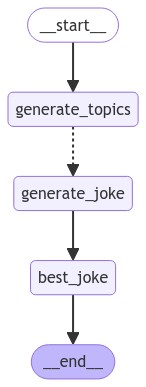

In [ ]:
from IPython.display import Image
from langgraph.graph import END, StateGraph, START

# 构建图：把上述各个节点与边组合成完整图
graph = StateGraph(OverallState)
graph.add_node("generate_topics", generate_topics)
# 并行生成笑话的节点
graph.add_node("generate_joke", generate_joke)
# 选择最佳笑话的节点
graph.add_node("best_joke", best_joke)
# 起始 -> 生成子主题
graph.add_edge(START, "generate_topics")
# 条件边：为每个子主题发送到 generate_joke，并行执行
graph.add_conditional_edges("generate_topics", continue_to_jokes, ["generate_joke"])
# Map -> Reduce
graph.add_edge("generate_joke", "best_joke")
# 结束
graph.add_edge("best_joke", END)

# 编译图
app = graph.compile()
Image(app.get_graph().draw_mermaid_png())

In [ ]:
# 调用图：以输入主题触发生成与选择流程
for s in app.stream({"topic": "animals"}):
    print(s)  # 逐步输出每一步状态，便于初学者观察执行顺序

{'generate_topics': {'subjects': ['mammals', 'reptiles', 'birds']}}
{'generate_joke': {'jokes': ["Why don't mammals ever get lost? Because they always follow their 'instincts'!"]}}
{'generate_joke': {'jokes': ["Why don't alligators like fast food? Because they can't catch it!"]}}
{'generate_joke': {'jokes': ["Why do birds fly south for the winter? Because it's too far to walk!"]}}
{'best_joke': {'best_selected_joke': "Why don't alligators like fast food? Because they can't catch it!"}}


## Studio（可视化与本地开发）

**⚠️ 说明**

自课程视频录制后，Studio 已更新支持“本地运行并在浏览器打开”。这现在是推荐方式（而不是使用视频中演示的桌面应用）。

- 本地开发服务器说明见文档：[LangGraph Studio 本地开发服务](https://langchain-ai.github.io/langgraph/concepts/langgraph_studio/#local-development-server)
- 如何运行见文档：[运行本地 Studio](https://langchain-ai.github.io/langgraph/how-tos/local-studio/#run-the-development-server)

在本模块的 `/studio` 目录中，执行：

```
langgraph dev
```

你将看到类似输出：
```
- 🚀 API: http://127.0.0.1:2024
- 🎨 Studio UI: https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024
- 📚 API Docs: http://127.0.0.1:2024/docs
```

用浏览器打开 Studio UI：`https://smith.langchain.com/studio/?baseUrl=http://127.0.0.1:2024`。

我们将把上面的图在 Studio 中加载，对应到 `module-4/studio/langgraph.json` 中配置的 `module-4/studio/map_reduce.py`。